# `6COM2007-0105-2025 IAS Coursework: Adaptive Model Development Project PART - 2`

## `Admissibility-Aware Offline Actor-Critic Learning for Safer ICU-Sepsis Treatment Decisions`

### AUTHOR: RIYA BASAK


# `Plot interpretation and convergence`

The overall performance comparison shows the main return-safety trade-off. VOAC achieved the highest survival because it was the least restricted actor-critic model and could directly optimise the Bellman return objective. However, this higher return came with high inadmissibility and weak expert agreement, suggesting that the unrestricted actor-critic policy relied more on poorly supported action regions. LAADAN-AC achieved slightly lower survival, but with zero inadmissibility and the strongest expert match. This was expected from the design: LAADAN-AC was built to trade a small amount of raw reward for safer and more supported action selection.

The benchmark reference comparison gives context for the learned policies. The optimal reference remains higher, so the benchmark was not fully solved. This is reasonable because the optimal reference is computed directly from the known MDP, while the neural models learn through function approximation and regularised objectives. 

The gap to the optimal reference does not indicate a design fault in LAADAN-AC or the baselines. The optimal policy is computed directly from the known transition and reward tables of the benchmark MDP, so it represents an ideal dynamic-programming reference with full access to the environment model. In contrast, BC, CQL, VOAC and LAADAN-AC are learned neural policies trained with finite optimisation, 47-dimensional state-centre features, regularisation and model-specific constraints. LAADAN-AC is also intentionally safety-guided, so it does not optimise survival alone; it trades some raw return for admissibility, expert consistency and safer action selection. Therefore, the gap was expected: the aim was not to beat the exact optimal policy, but to show whether the proposed safety-guided actor-critic improves the return-safety trade-off compared with realistic learned baselines.

The survival-during-training curve stabilised early. Using the 95%-of-best-survival rule, all methods reached this level by the first evaluation point at epoch 10. Because evaluation was recorded every 10 epochs, epoch 10 is the earliest measurable convergence point. This does not mean all models were equally good after epoch 10. It means survival alone was not sensitive enough to separate the methods, so safety and alignment metrics were needed.

The inadmissible-action curve gives the clearest evidence for the project aim. VOAC kept a high inadmissible-action rate because its actor was not restricted by the benchmark support mask. LAADAN-AC stayed at zero inadmissibility because masking, cost modelling and the Lagrangian penalty directly changed the action-selection process. This confirms that the safety mechanisms affected behaviour rather than only adding extra losses in the code.

The action-preference heatmap supports the numerical alignment results. BC and LAADAN-AC produced action patterns closer to the expert policy, while VOAC selected noticeably different actions. This explains why VOAC had high survival but very low expert argmax match, while LAADAN-AC had slightly lower survival but much stronger expert consistency.

The sensitivity plots show that LAADAN-AC was not dependent on one arbitrary setting. Conservative alpha had the clearest effect: lower values slightly improved survival while inadmissibility stayed at zero. This suggests that too much conservatism can reduce return, but the admissibility mask still protects safety. Expert-KL and smoothness weights caused smaller changes in the tested range, suggesting that the main safety effect came from the mask and cost-aware design, while expert and smoothness terms refined alignment.

# `Displaying saved training and result plots`

The following code cell displays the plots generated from `summary.json` and saved in `results/train_results`. These plots show the model comparison, benchmark reference comparison, training convergence, inadmissible-action behaviour, learned action preferences, and LAADAN-AC hyperparameter sensitivity results discussed in the previous cell. 

### Overall Policy Performance

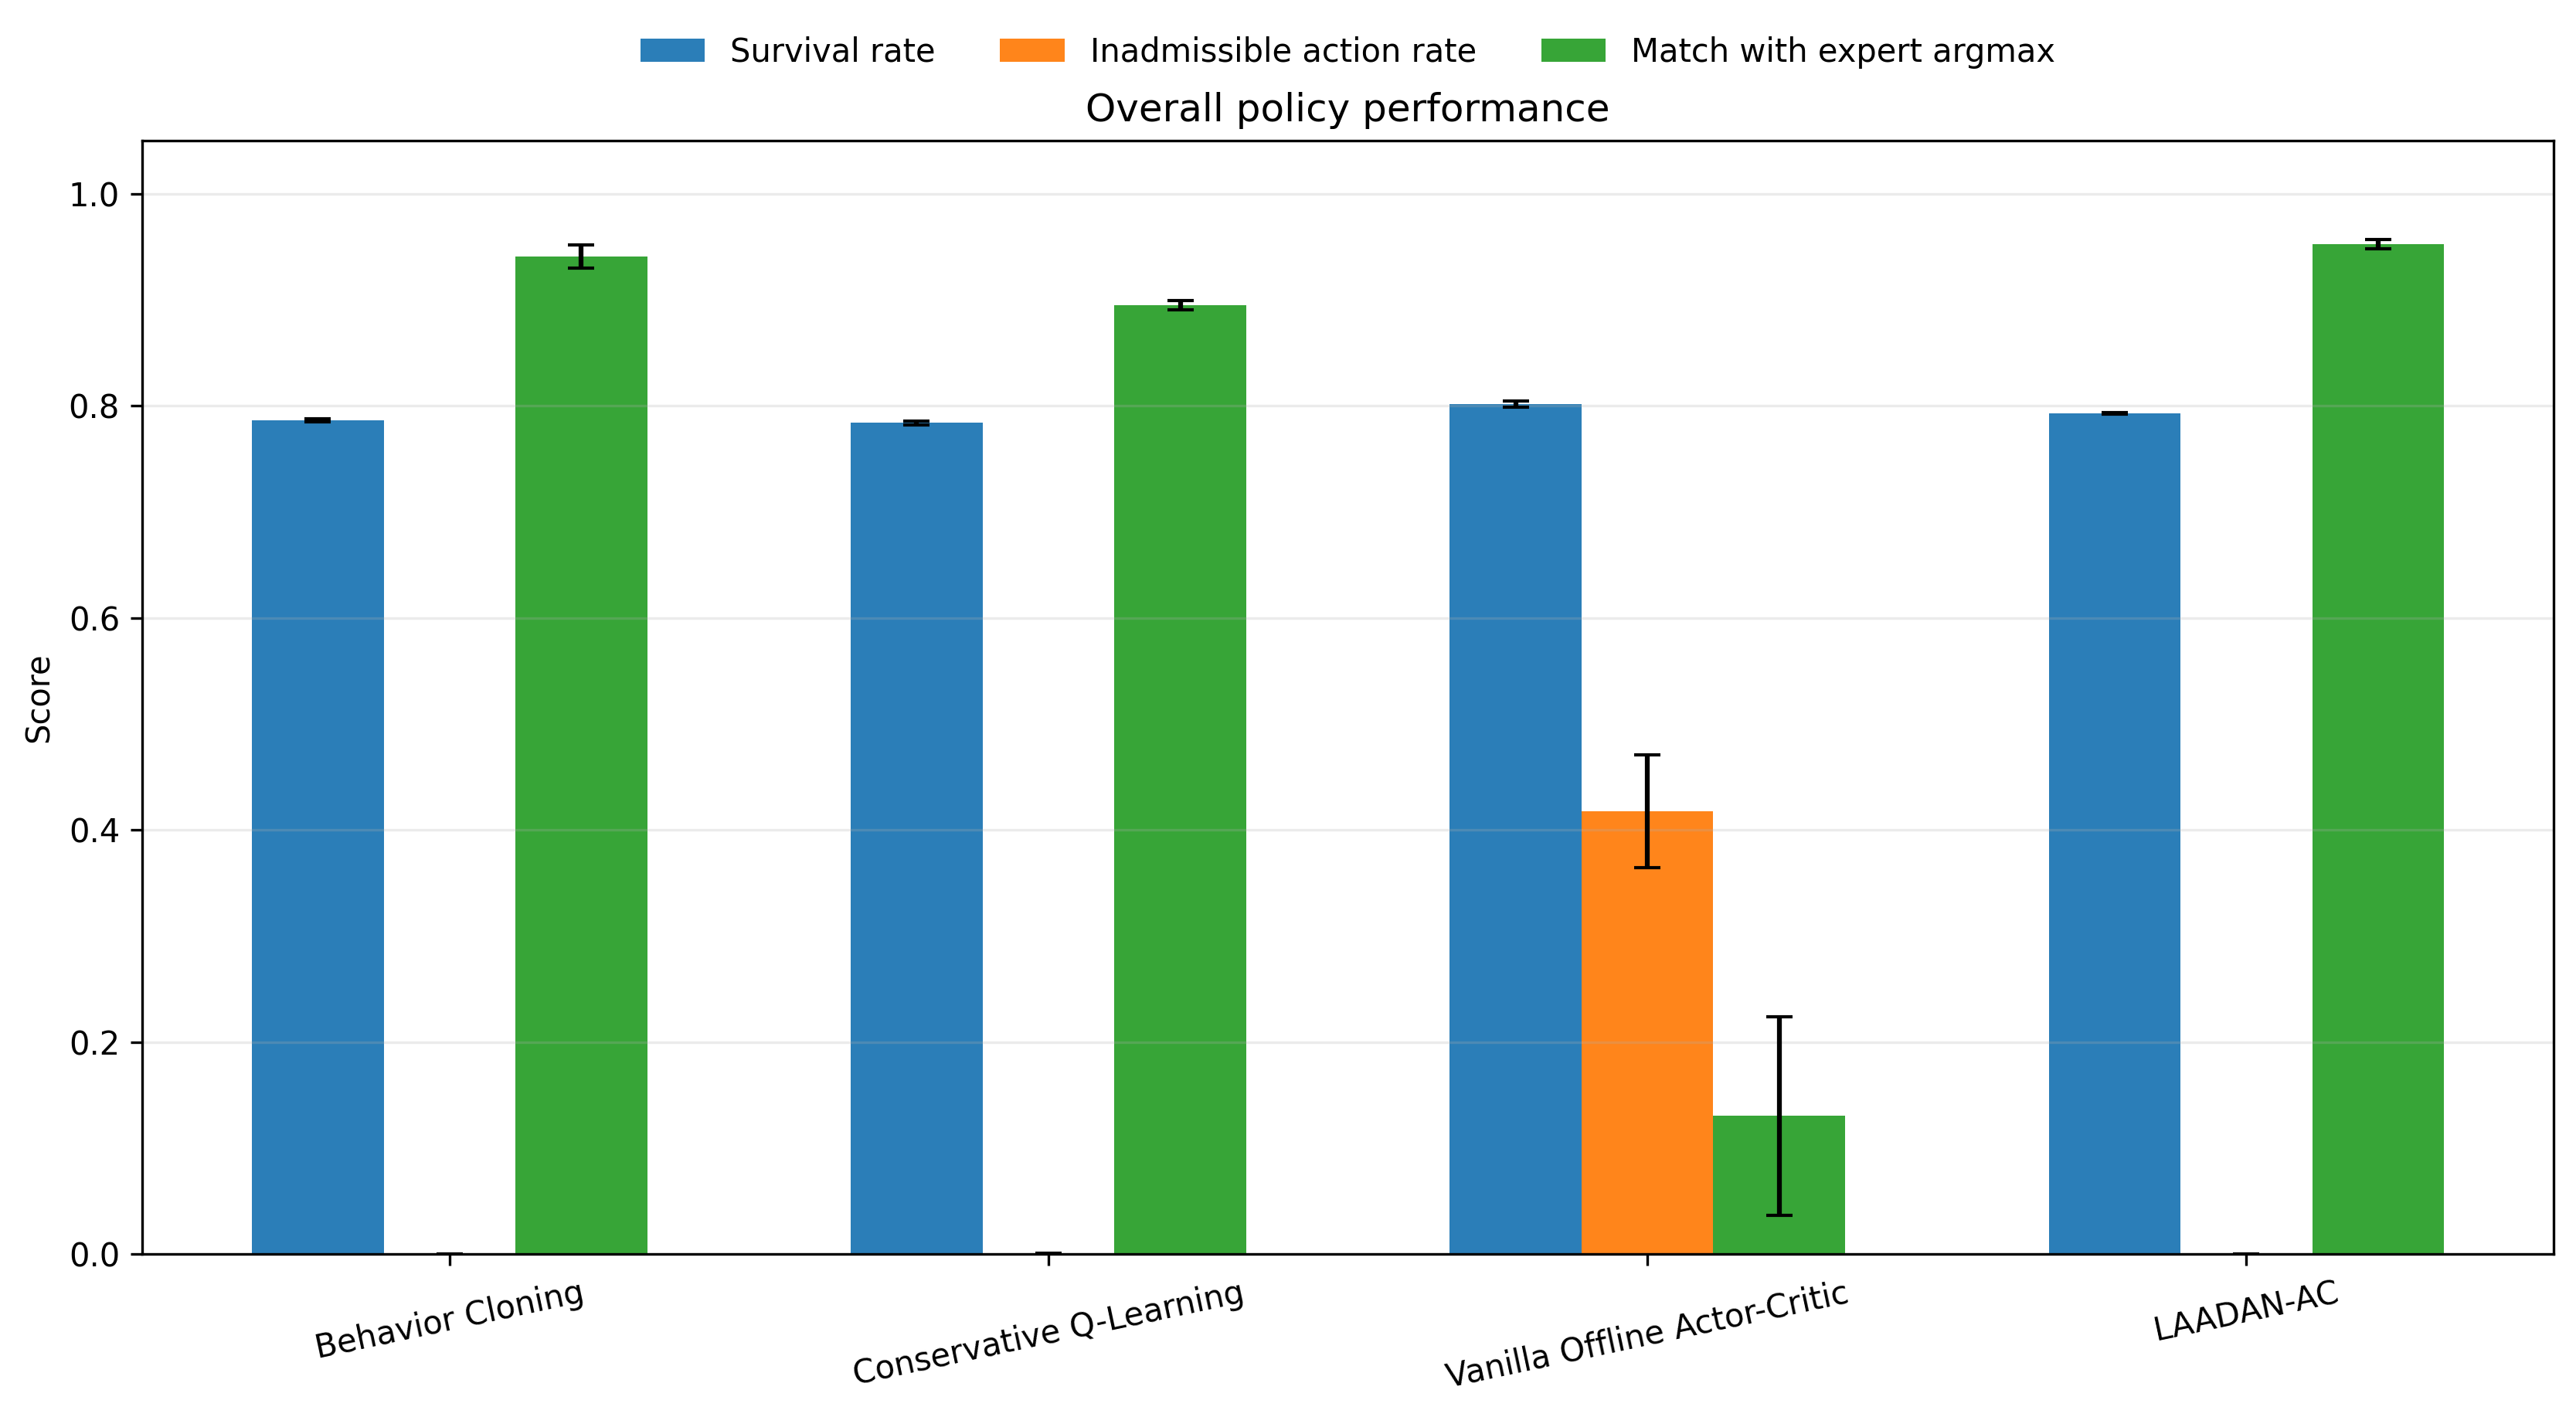

### Benchmark Reference Comparison

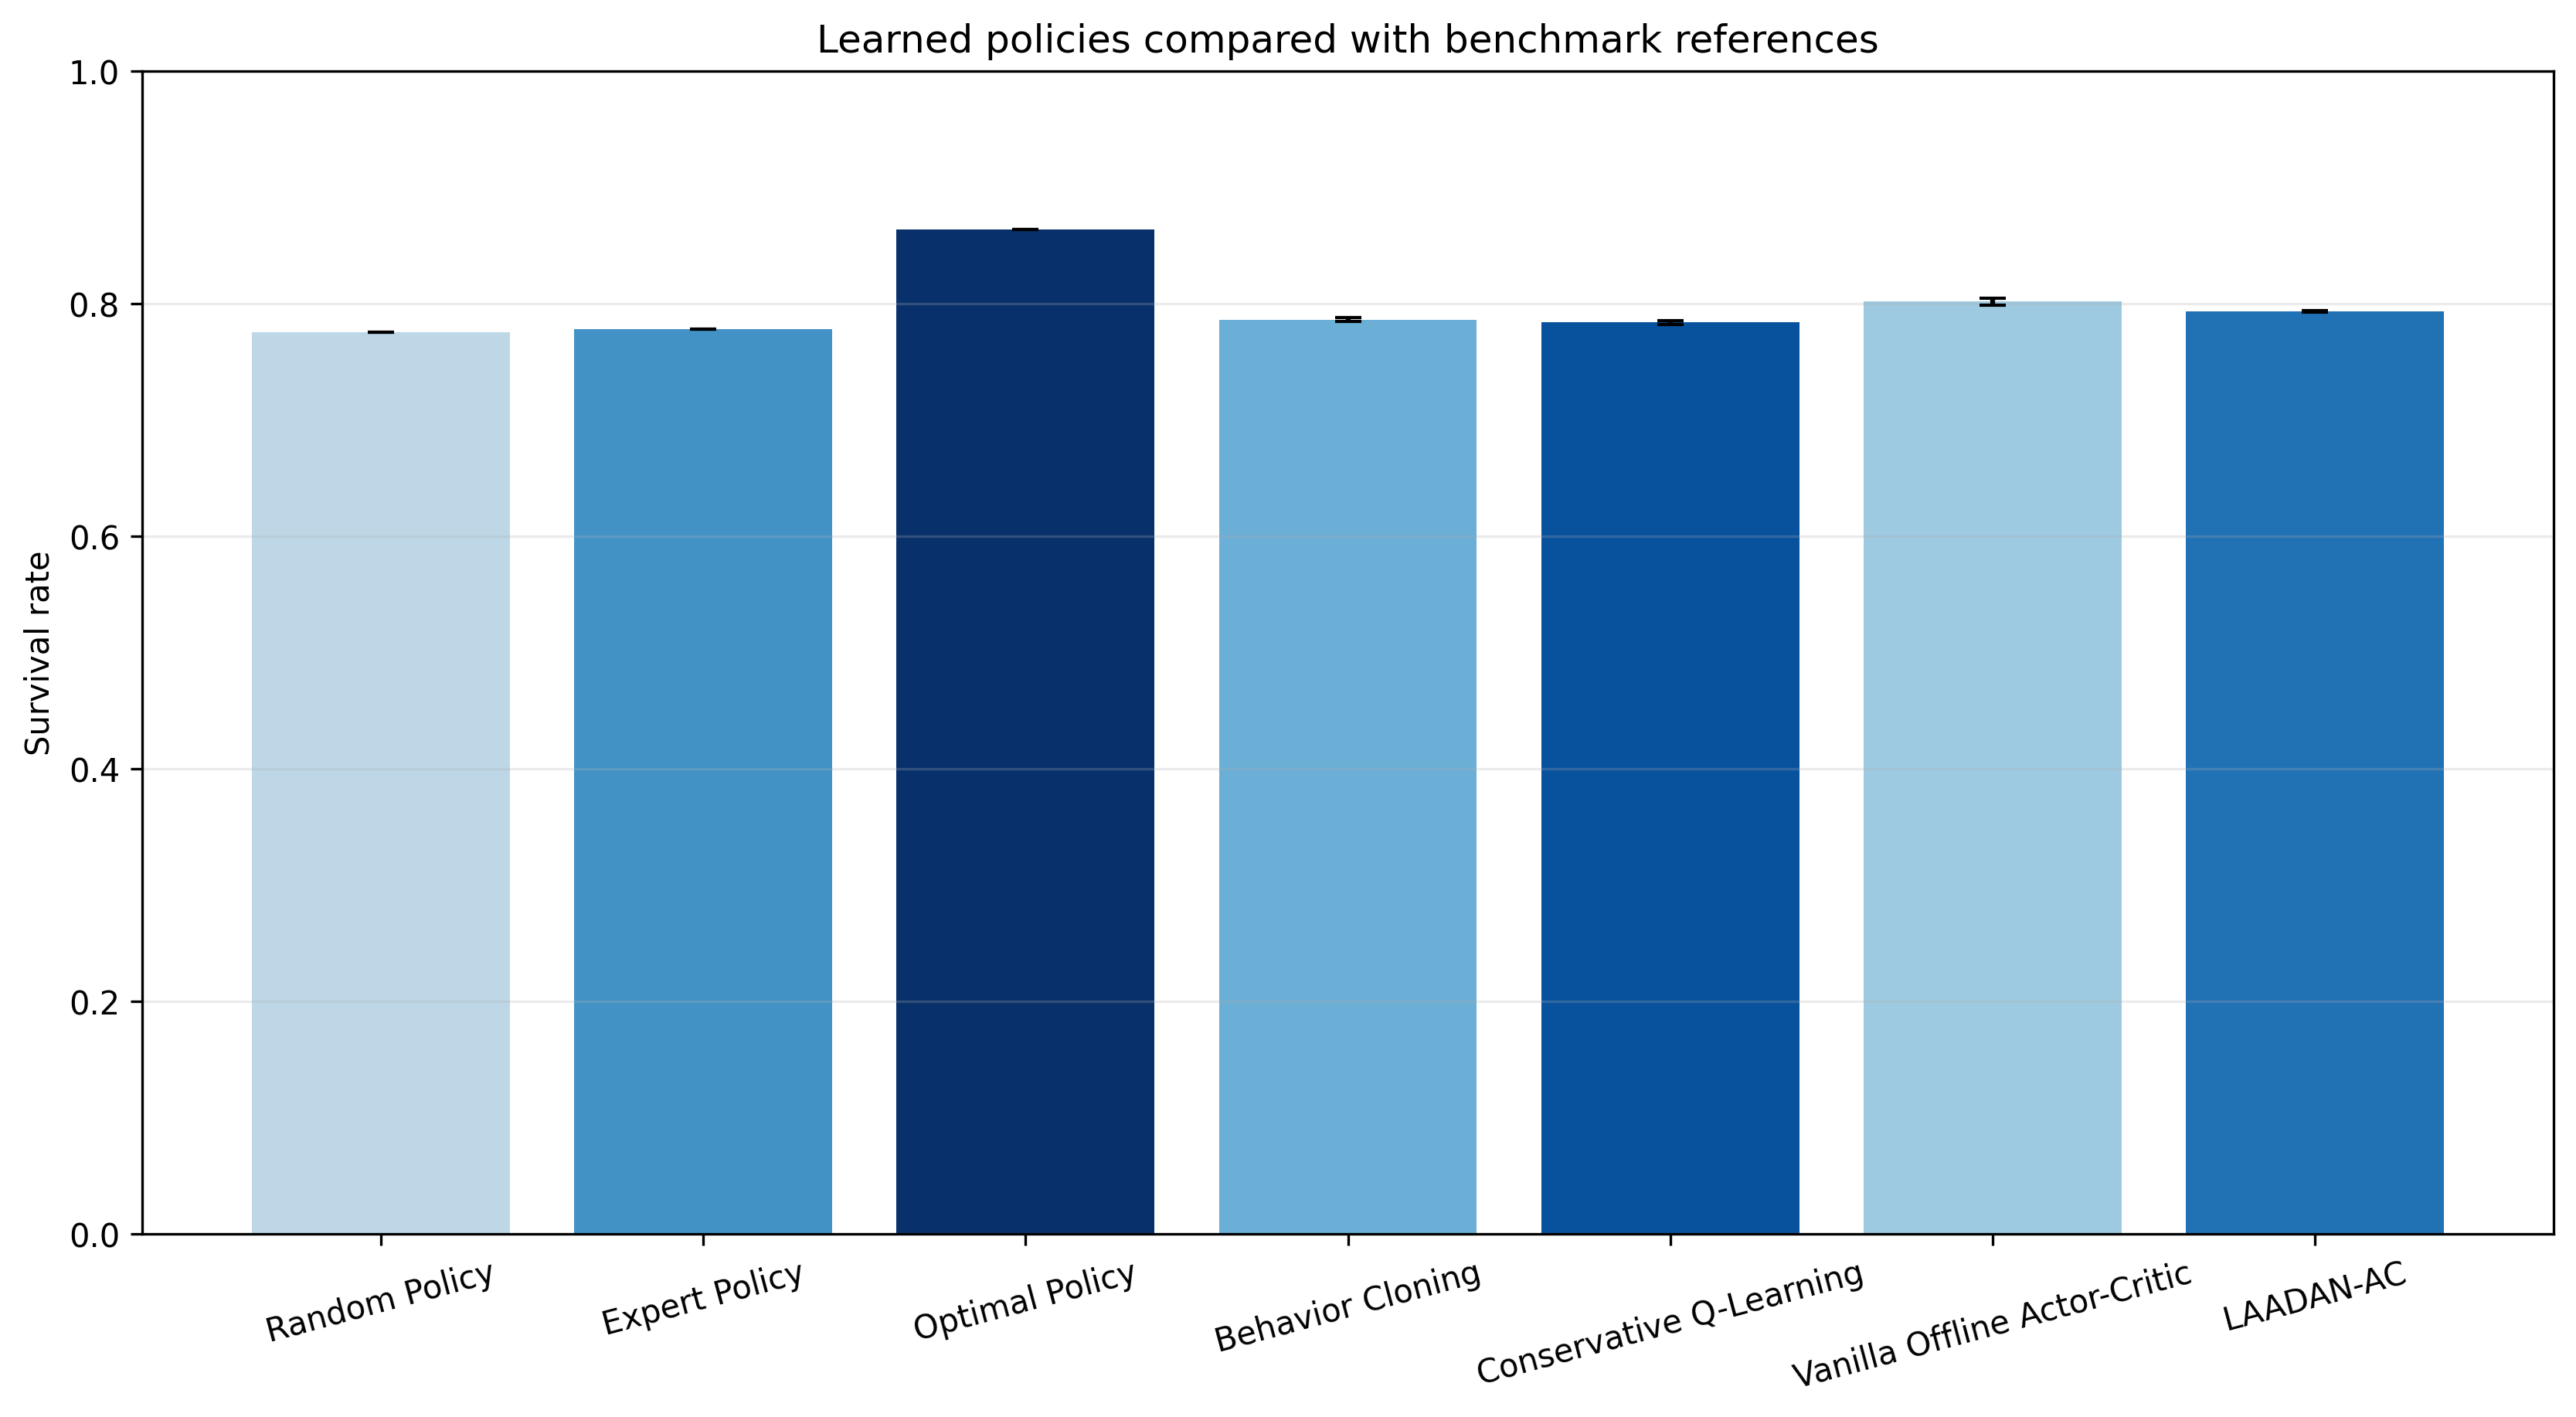

### Survival During Training

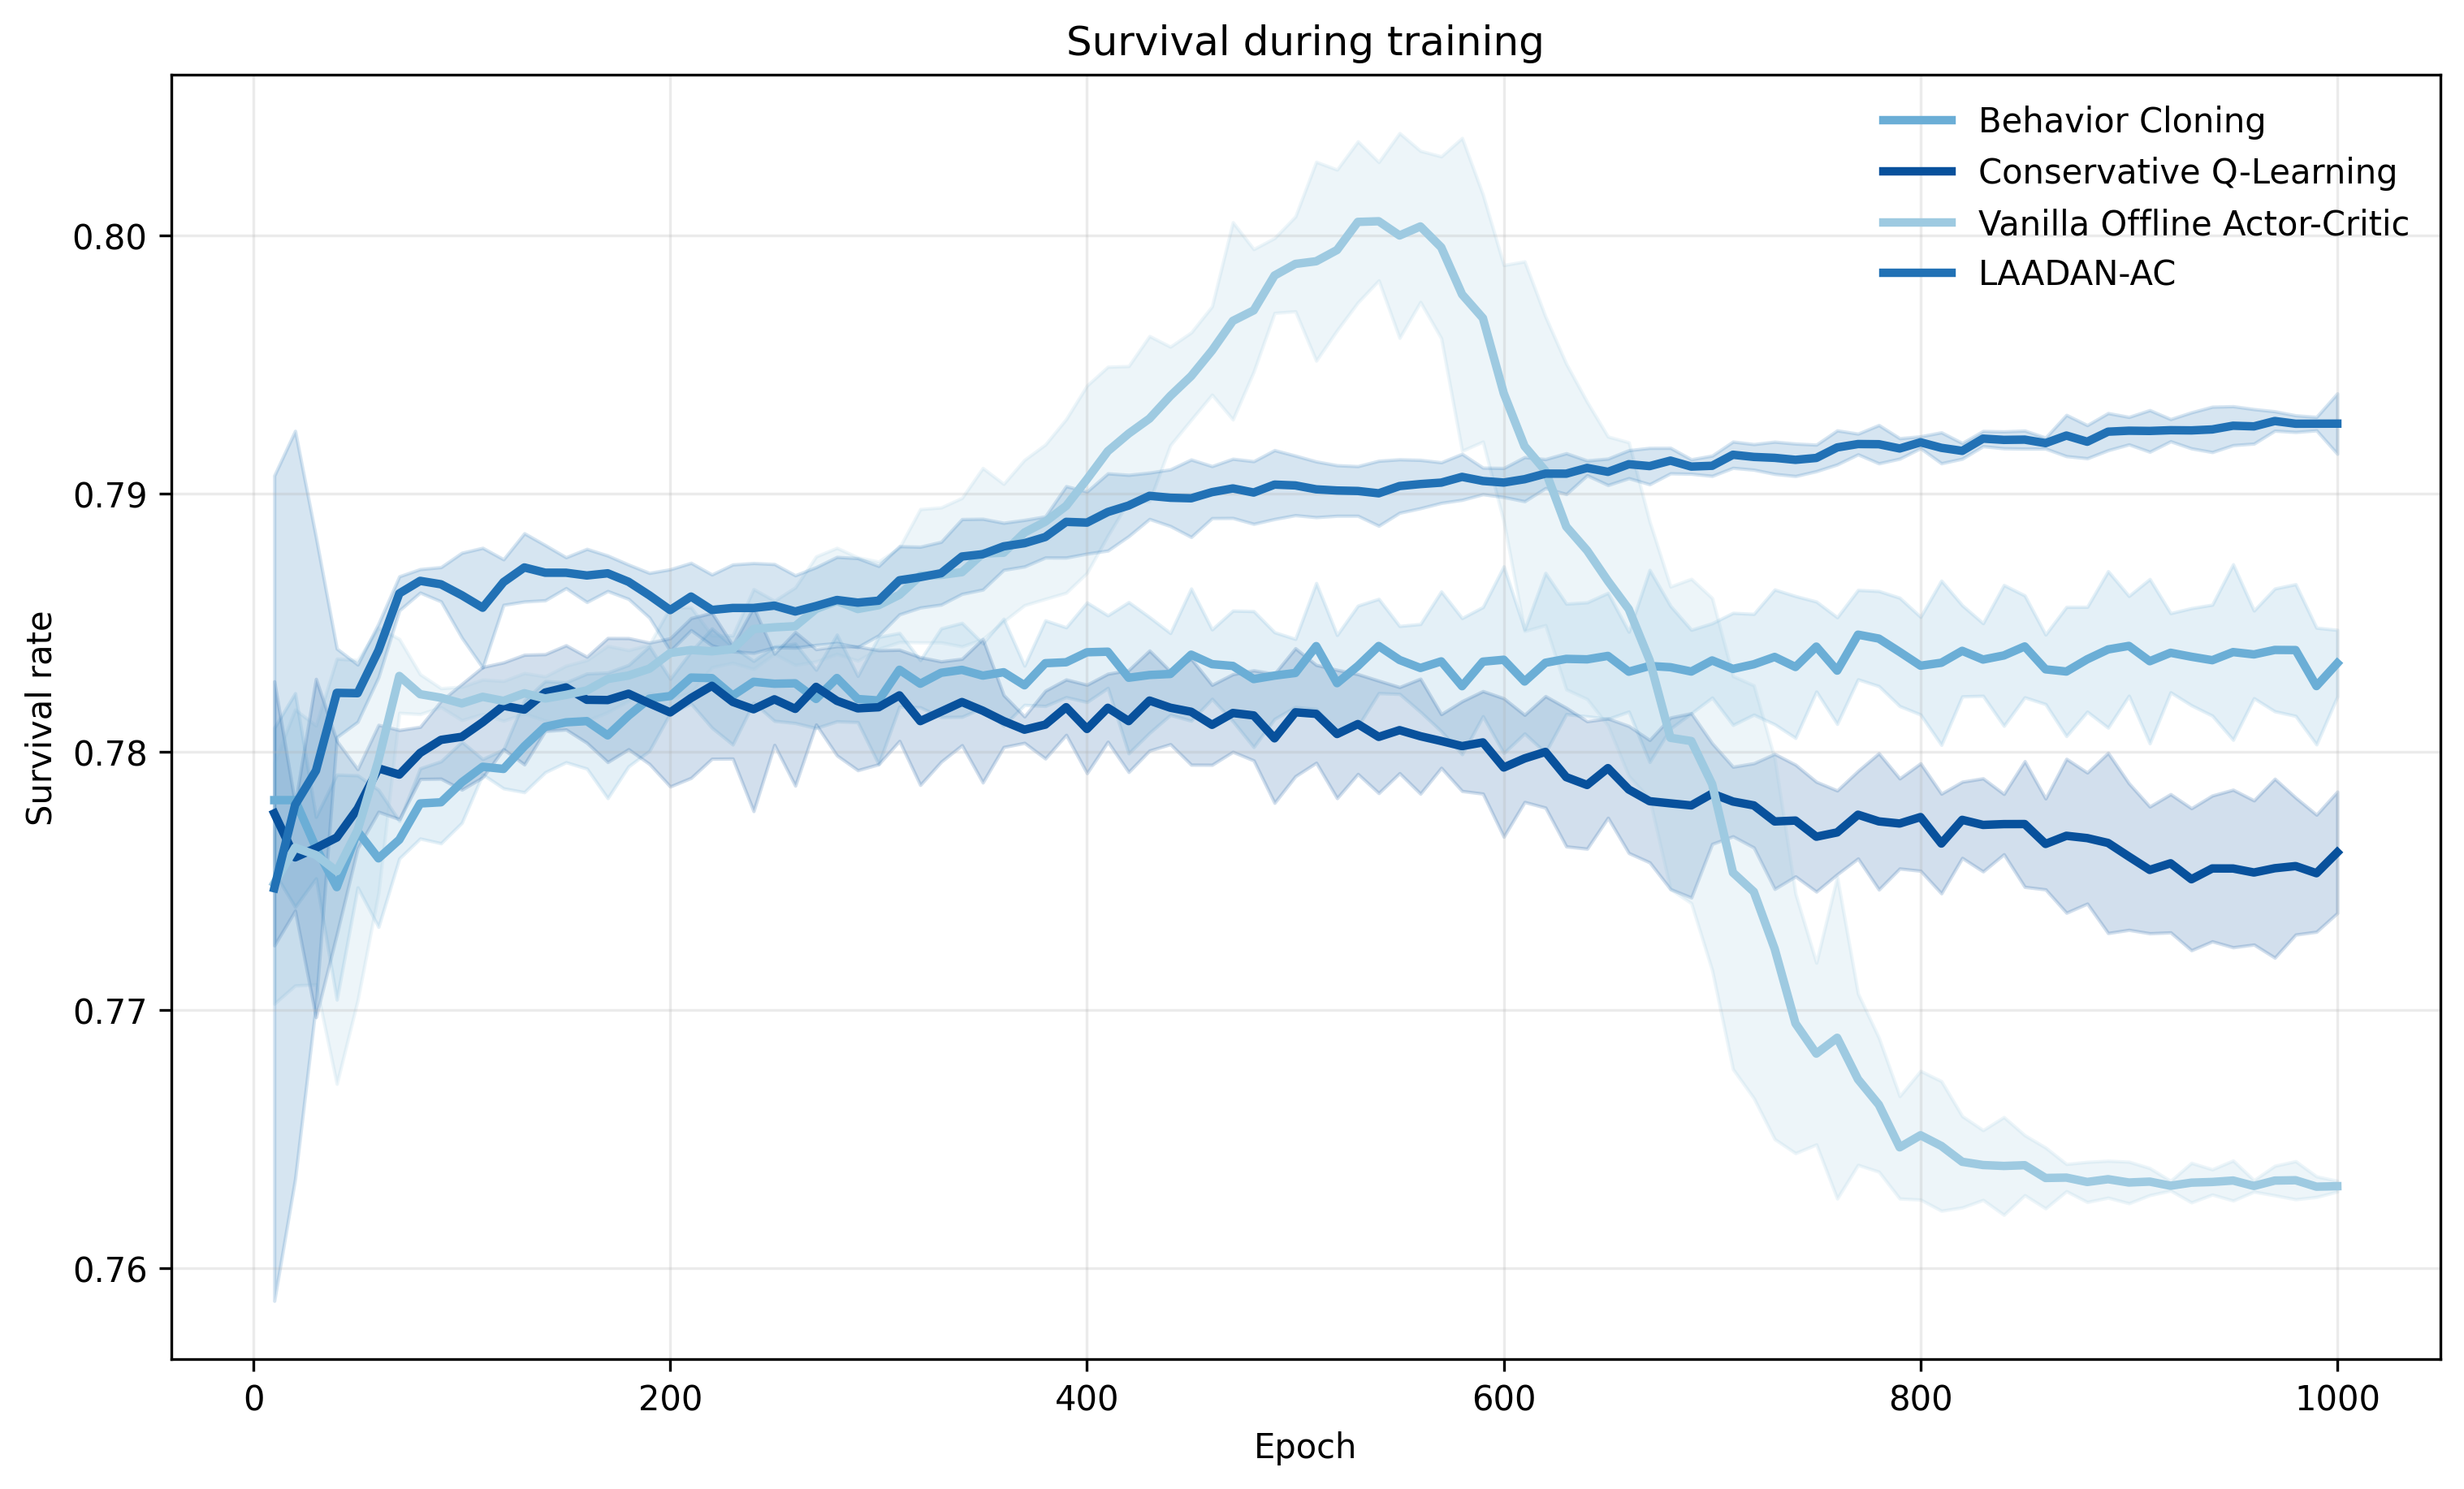

### Inadmissible Actions During Training

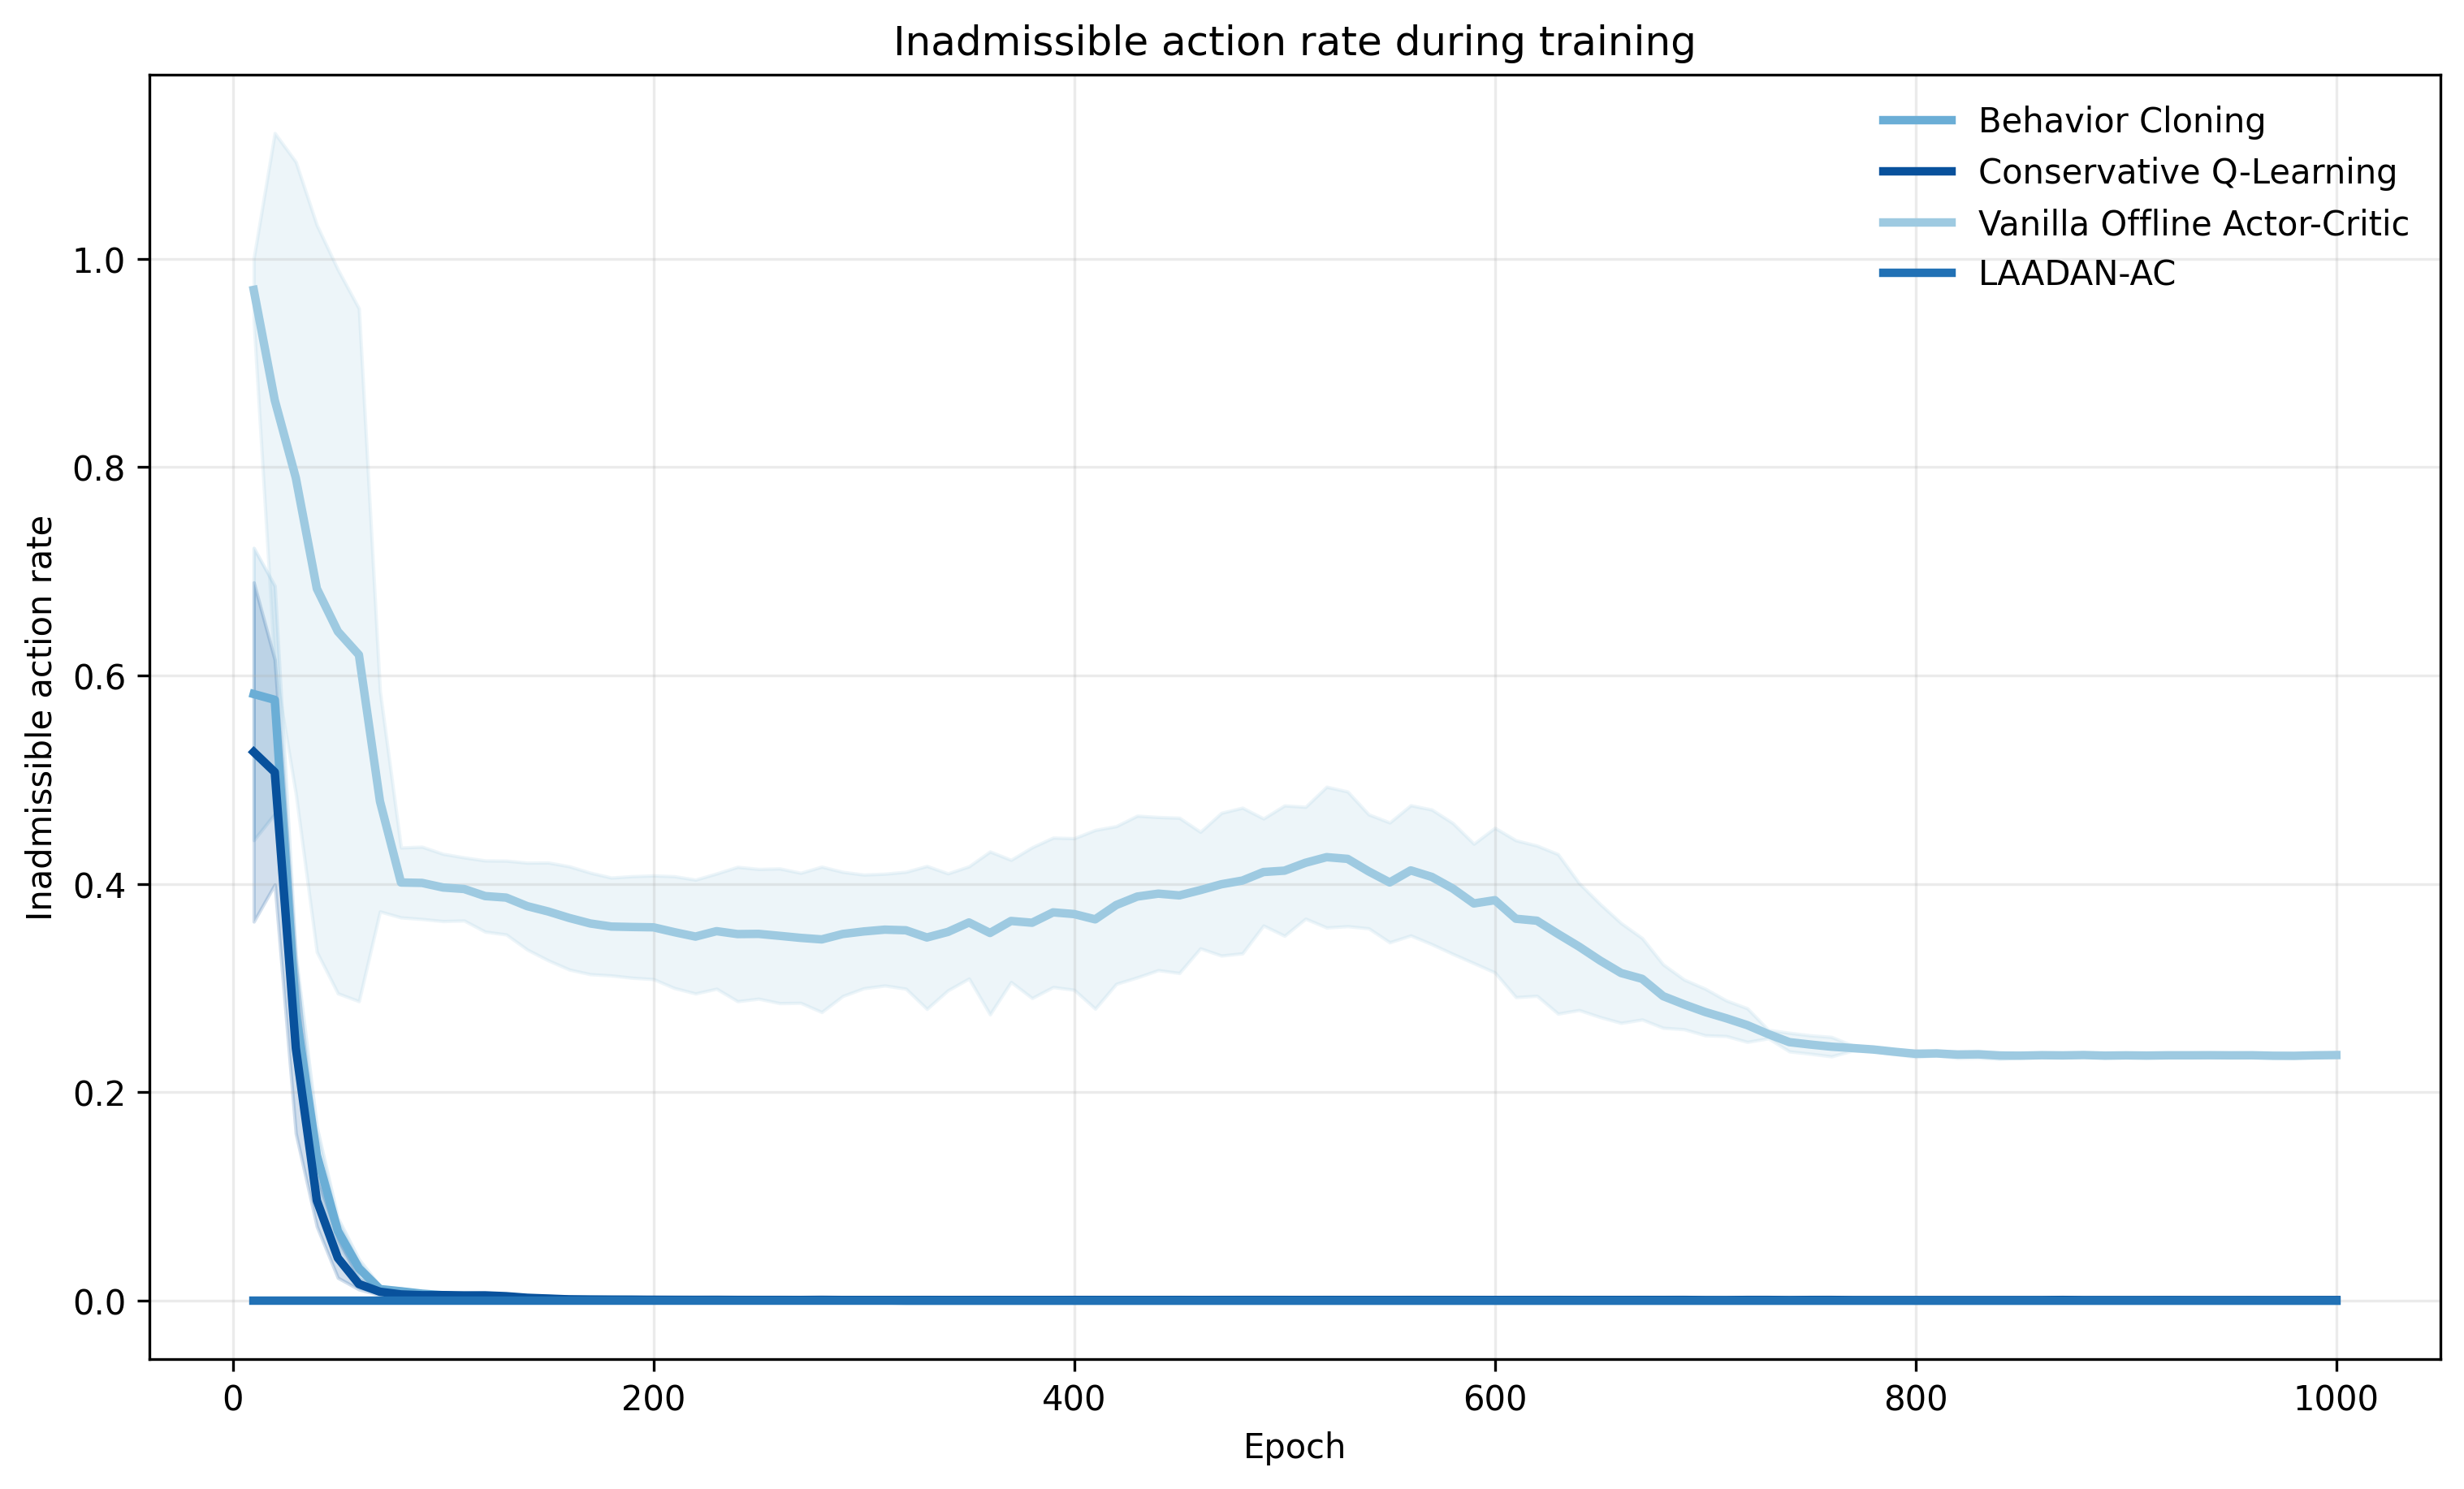

### Action Preferences Heatmap

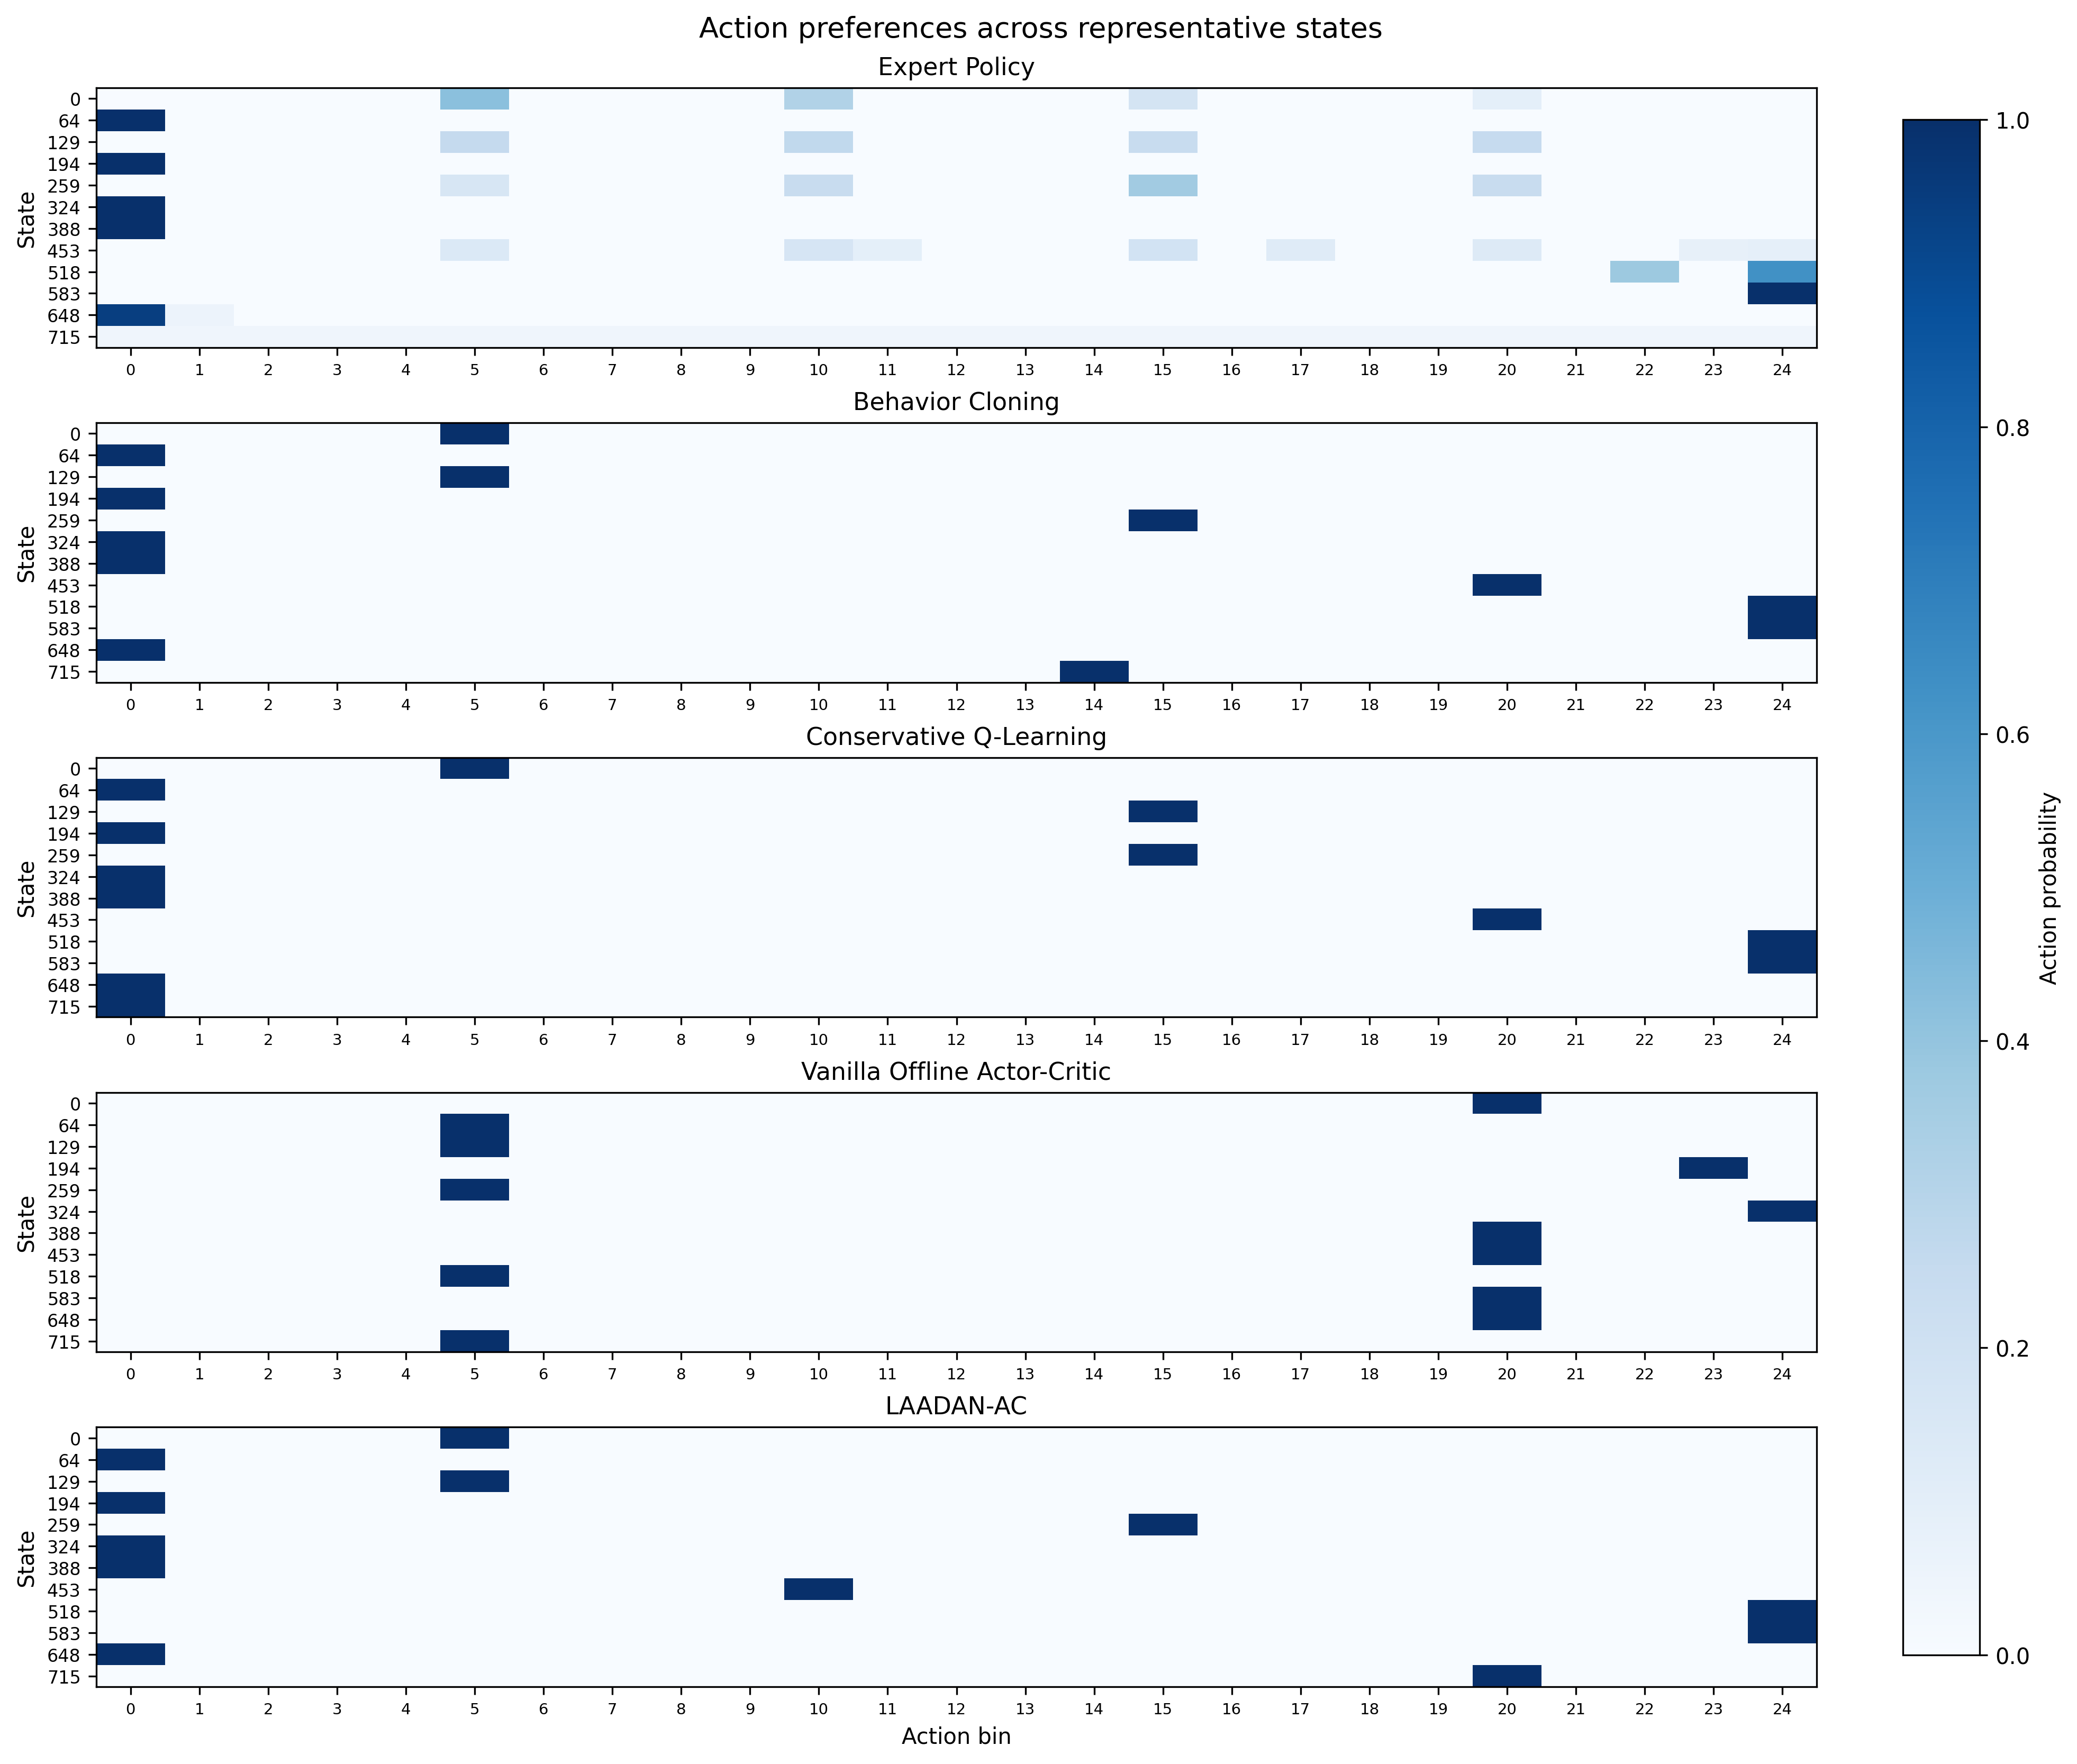

### Conservative Alpha

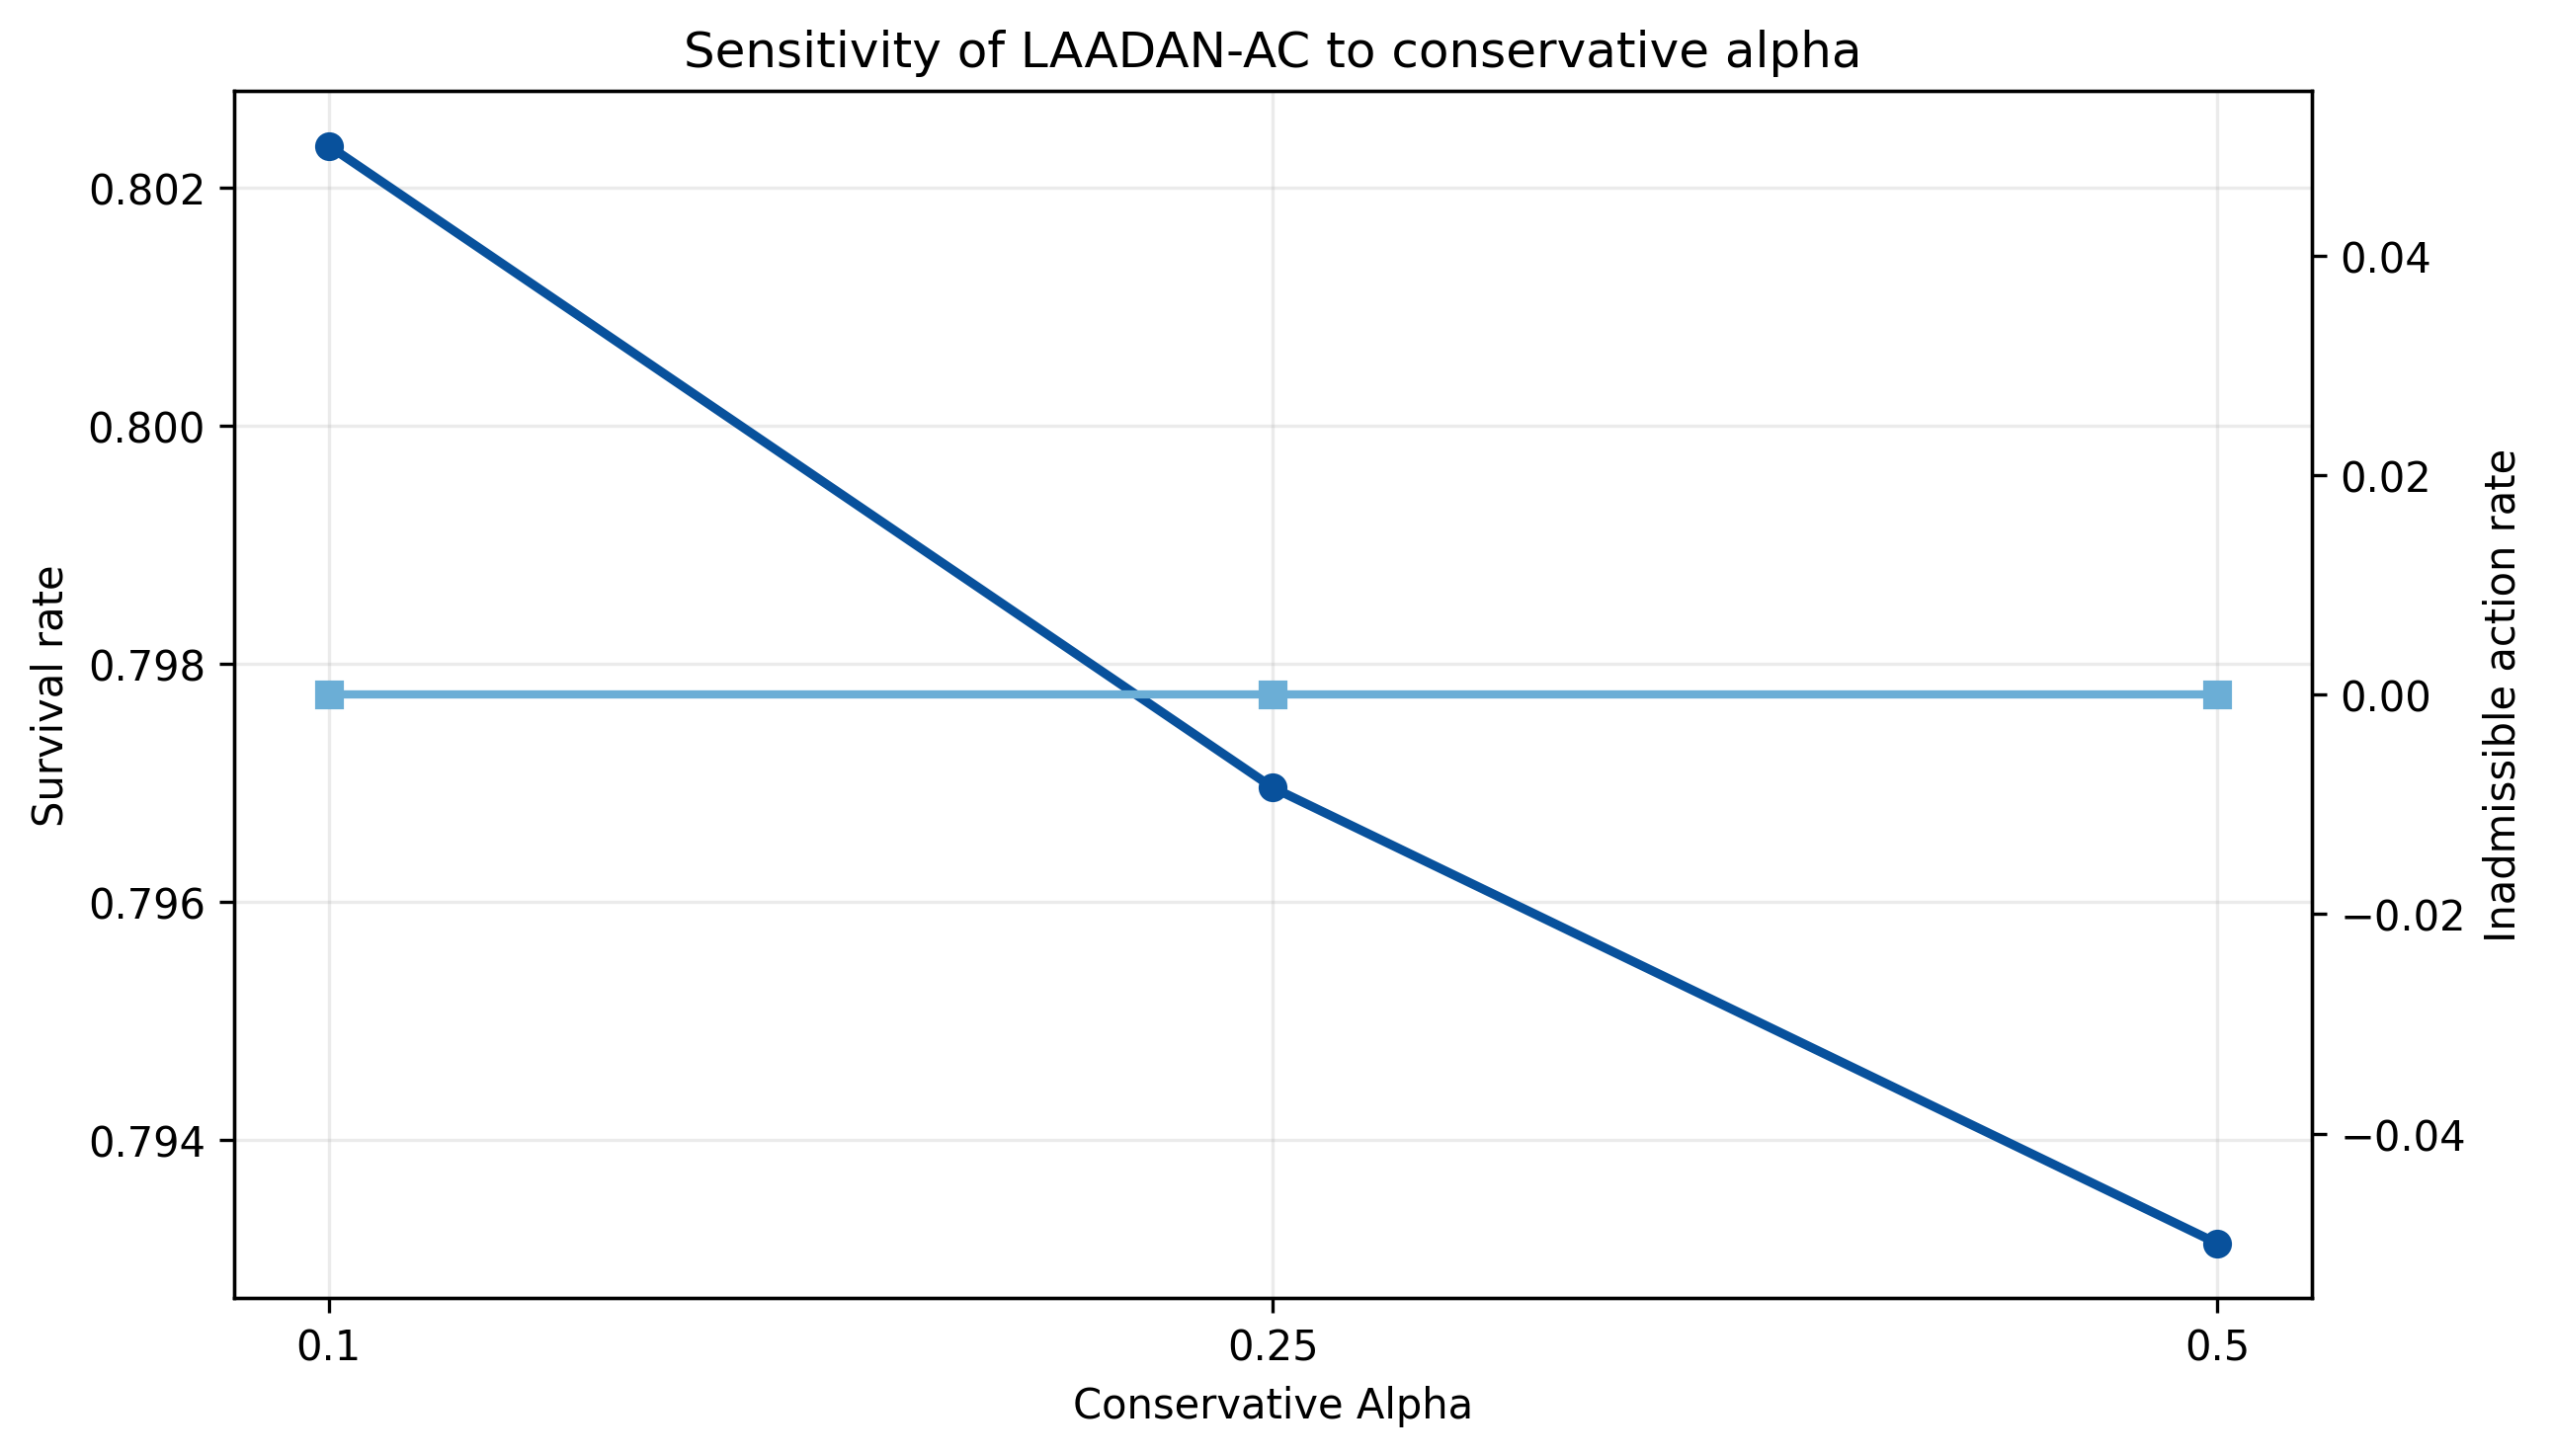

### Expert Kl Weight

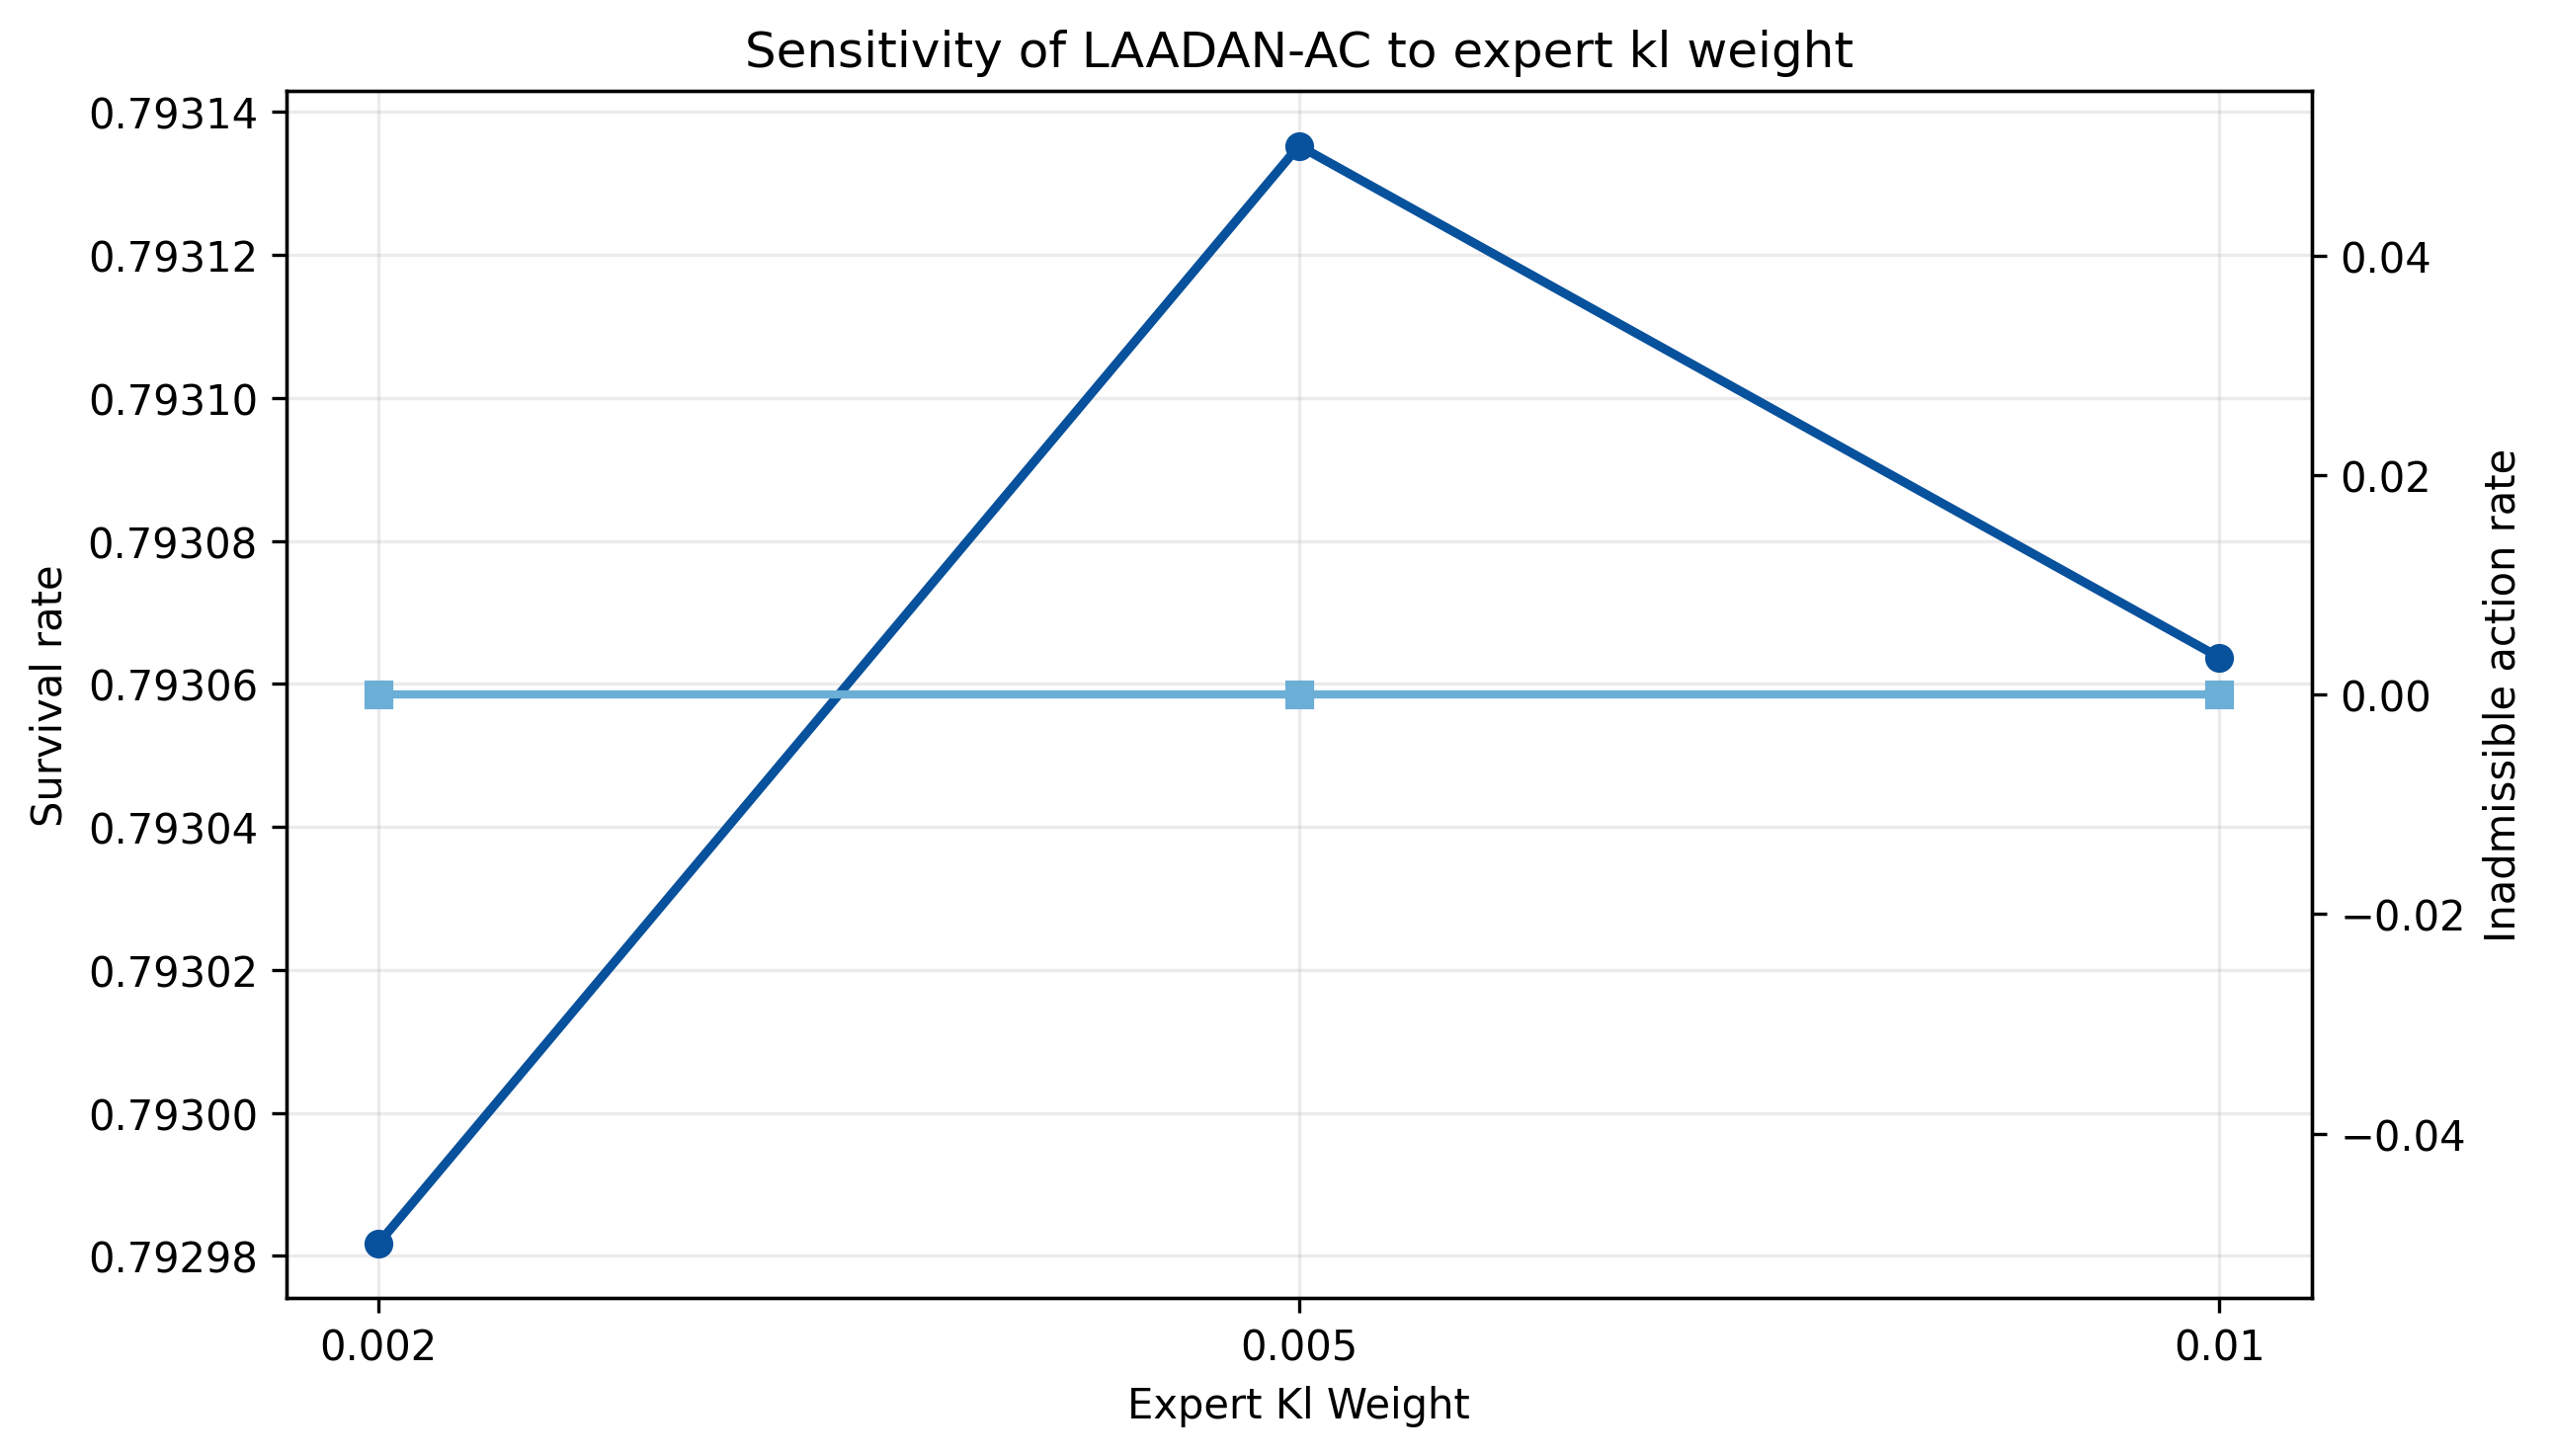

### Smoothness Weight

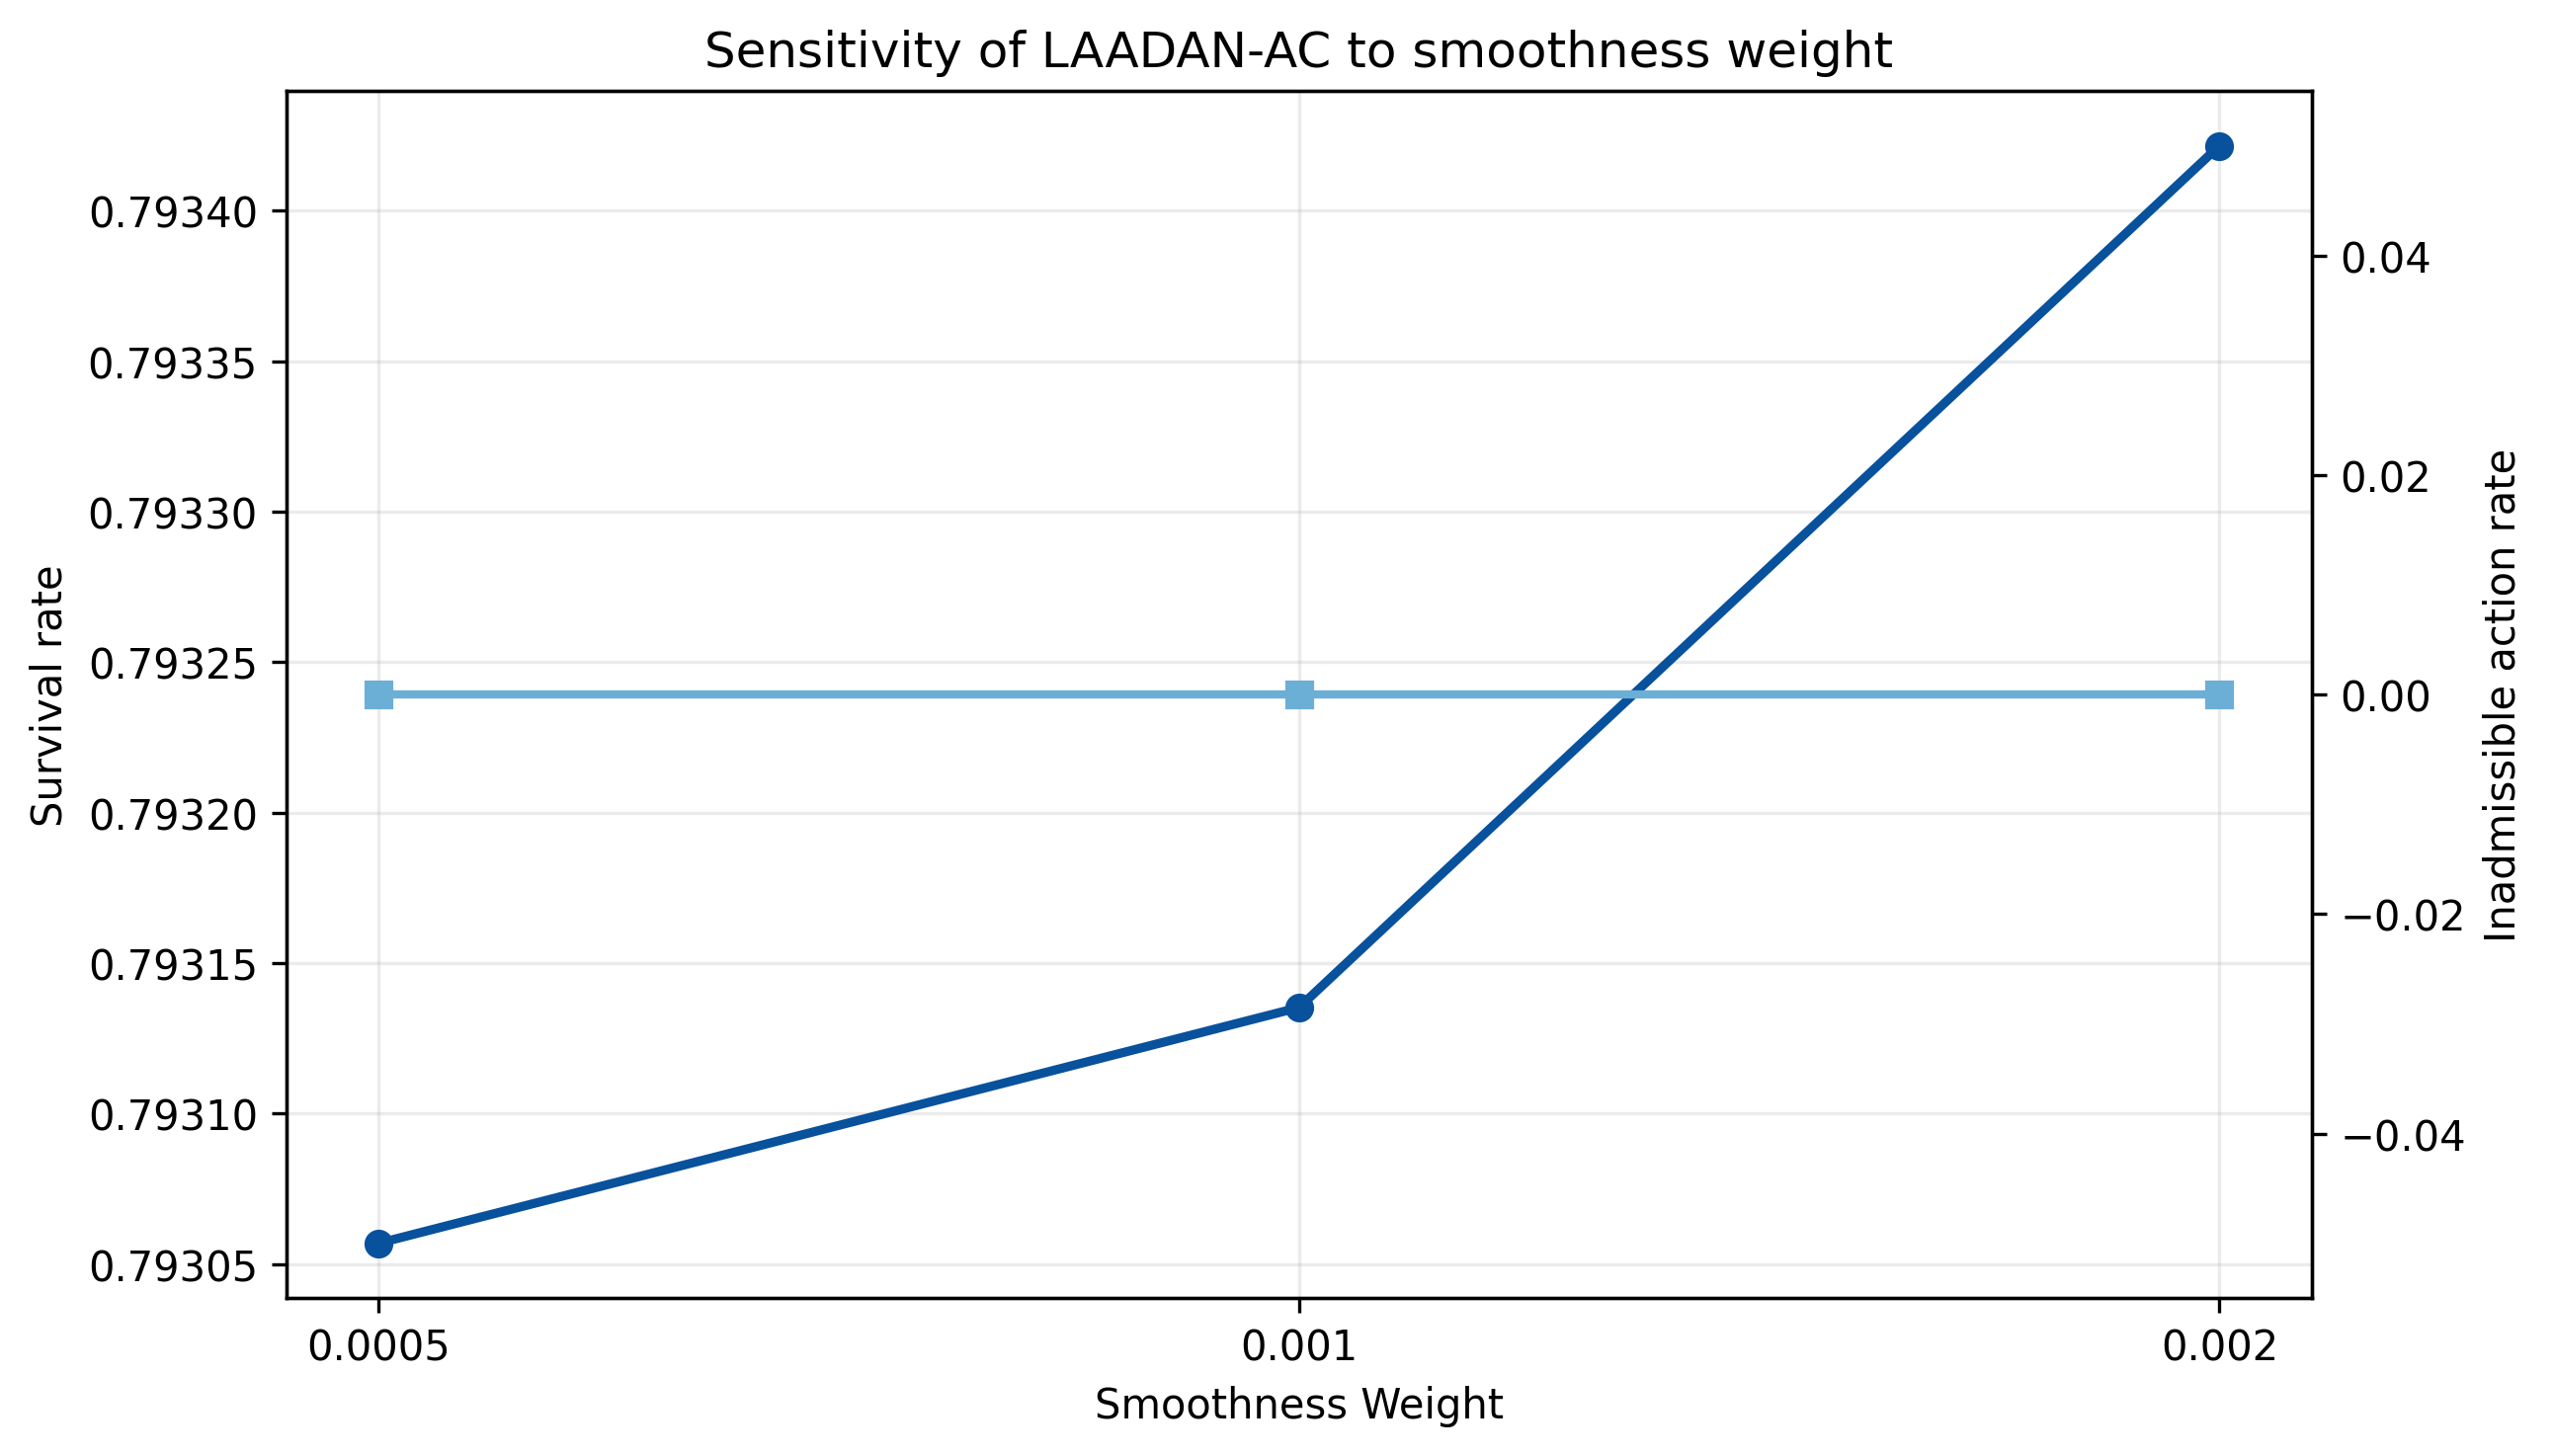

In [ ]:

# This cell displays the saved training and result plots from the experiment.
# The plots were already generated by plots.py and saved inside:
# results/train_plots/
#
# This does not recalculate the plots. It only loads the saved PNG files
# and shows them inside the notebook so the marker can view them easily.

from pathlib import Path
from IPython.display import display, Image, Markdown

# Folder where the generated plot images are stored.
plot_dir = Path("results/train_plots")

# List of plot files to display in the notebook.
# These include overall performance, benchmark comparison, training curves,
# policy heatmaps, and LAADAN-AC hyperparameter sensitivity plots.
plot_files = [
    "overall_policy_performance.png",
    "benchmark_reference_comparison.png",
    "survival_during_training.png",
    "inadmissible_actions_during_training.png",
    "action_preferences_heatmap.png",
    "conservative_alpha.png",
    "expert_kl_weight.png",
    "smoothness_weight.png",
]

# Looping through each expected plot file.
for plot_name in plot_files:
    
    # Building the full path to the current plot.
    plot_path = plot_dir / plot_name
    
    # If the plot file exists, displaying a readable heading and the image.
    if plot_path.exists():
        plot_title = plot_name.replace("_", " ").replace(".png", "").title()
        display(Markdown(f"### {plot_title}"))
        display(Image(filename=str(plot_path)))
    
    # If the plot is missing, printing its path so it is easy to debug.
    else:
        print(f"Missing plot: {plot_path}")

# `Discussion and evaluation`

The results are consistent with the theory of offline reinforcement learning. VOAC directly optimised expected return through Bellman like critic targets and actor updates, so it was expected to achieve the highest survival. However, because it had no admissibility mask, no expert regularisation and no cost constraint, it also selected many unsupported actions. This is the central offline RL risk: a policy can exploit value-estimation errors in fixed data and appear strong on reward while becoming unsafe or poorly supported (Kumar et al., 2020; Levine et al., 2020).

CQL reduced this failure mode because its conservative loss discourages over-optimistic Q-values. This explains why CQL had much lower inadmissibility than VOAC. However, CQL still did not match LAADAN-AC’s safety and alignment because it controlled value estimation, not the final actor policy through direct masking and expert-guided regularisation. Briefly, CQL made the critic more cautious, while LAADAN-AC made both the critic and the action-selection process safety-aware.

BC behaved as expected for an imitation baseline. It stayed close to the expert policy and achieved zero inadmissibility because it learned from expert supervision rather than freely maximising long-horizon return. Its weakness is also clear: copying the expert gives a stable and safe baseline, but it gives limited scope to improve the return-safety trade-off beyond the demonstrated policy.

LAADAN-AC produced the strongest balanced result. It did not beat VOAC on raw survival, but it achieved zero inadmissibility, the highest expert argmax match and strong soft-policy safety. This is the most important interpretation of the experiment: the best policy in this benchmark is not simply the one with the highest survival score. For offline safety-critical RL, the policy also needs to remain inside supported action regions and stay close to plausible expert behaviour.

This directly relates to the module theory. The project uses an MDP, Bellman value learning, actor-critic policy learning, function approximation, exact finite-horizon evaluation and the reward-against-safety trade-off. Unlike online RL, there was no live epsilon-style exploration. The main exploration issue appeared as a dataset-support problem: the model could exploit the fixed MDP by choosing actions that looked valuable but were weakly supported by the offline data. LAADAN-AC reduced this risk by combining admissibility-aware action selection with conservative, expert-guided and cost-aware learning.

The final testing step strengthens the result. The selected checkpoints were reloaded, the benchmark was rebuilt from the saved configuration, and the metrics were recomputed. All models passed the saved-against-recomputed checks.

# `Limitations`

The main limitation is that this was a fixed benchmark study, not a real clinical deployment. Model selection and evaluation used the released ICU-Sepsis MDP, so the results show reproducible benchmark performance rather than real-world clinical generalisation. The benchmark is also simplified because it uses discrete states, discrete treatment actions and fixed transition tables, rather than full patient histories, continuous medication doses or changing real-world conditions (Choudhary, Gupta and Thomas, 2024; Gottesman et al., 2019).

A second limitation is that LAADAN-AC’s safety mechanism was tested only with the benchmark’s admissibility mask and cost signal. In a real adaptive system, these safety constraints would need separate validation before use, because safe reinforcement learning requires reliable constraint definitions, not only high reward (García and Fernández, 2015; Achiam et al., 2017).



# `Conclusion and future work`

The project tested whether a safety-guided offline actor-critic could preserve strong survival while avoiding unsupported actions. This aim was achieved within the ICU-Sepsis benchmark. VOAC achieved the highest raw survival, but it also produced high inadmissibility and weak expert agreement. LAADAN-AC achieved slightly lower survival, but reached zero inadmissibility, the highest expert argmax match and strong soft-policy safety.

This result was expected from the proposed design. LAADAN-AC was not designed to maximise reward at any cost; it was designed to balance reward with safety, dataset support and expert consistency. This matches safe reinforcement-learning theory, where the policy should optimise return while respecting constraints (García and Fernández, 2015; Achiam et al., 2017). Therefore, the main finding is that the best policy in a safety-critical offline benchmark is not only the one with the highest return, but the one with the strongest return-safety trade-off.

Future work should address the current limitations by testing LAADAN-AC in more realistic adaptive-control settings. For robotics, this would require continuous actions, partial-observation handling, simulation-based testing and stronger real-time safety checks, because robot controllers usually operate with continuous movement and uncertain sensor information (Kober, Bagnell and Peters, 2013). For social robotics, the same LAADAN-AC idea could be adapted by treating unsafe or socially inappropriate behaviours as constrained actions. The admissibility mask could represent safe action regions, expert regularisation could use human demonstrations, and the Lagrangian term could penalise violations of comfort, predictability or human-safety constraints (Lasota, Fong and Shah, 2017; Ravichandar et al., 2020). This could extend the project’s core idea from sepsis benchmarking towards safer human-robot interaction (HRI) adaptive agents.

# `References`

Achiam, J., Held, D., Tamar, A. and Abbeel, P. (2017) Constrained policy optimization, in Proceedings of the 34th International Conference on Machine Learning (ICML 2017), Proceedings of Machine Learning Research, 70, pp. 22-31. https://doi.org/10.48550/arXiv.1705.10528

Altman, E. (1999) Constrained Markov Decision Processes. Boca Raton, FL: Chapman & Hall/CRC. https://doi.org/10.1201/9781315140223

Choudhary, K., Gupta, D. and Thomas, P.S. (2024) ICU-Sepsis: a benchmark MDP built from real medical data, in Proceedings of the Reinforcement Learning Conference (RLC 2024). https://doi.org/10.48550/arXiv.2406.05646

García, J. and Fernández, F. (2015) A comprehensive survey on safe reinforcement learning, Journal of Machine Learning Research, 16, pp. 1437-1480. Available at: https://www.jmlr.org/papers/v16/garcia15a.html (Accessed: 26 March 2026).

Gottesman, O., Johansson, F., Komorowski, M., Faisal, A., Sontag, D., Doshi-Velez, F. and Celi, L.A. (2019) Guidelines for reinforcement learning in healthcare, Nature Medicine, 25(1), pp. 16-18. https://doi.org/10.1038/s41591-018-0310-5

Haarnoja, T., Zhou, A., Abbeel, P. and Levine, S. (2018) Soft actor-critic: off-policy maximum entropy deep reinforcement learning with a stochastic actor, in Proceedings of the 35th International Conference on Machine Learning (ICML 2018), Proceedings of Machine Learning Research, 80, pp. 1861-1870. https://doi.org/10.48550/arXiv.1801.01290

Harris, C.R., Millman, K.J., van der Walt, S.J., Gommers, R., Virtanen, P., Cournapeau, D., Wieser, E., Taylor, J., Berg, S., Smith, N.J., Kern, R., Picus, M., Hoyer, S., van Kerkwijk, M.H., Brett, M., Haldane, A., del Río, J.F., Wiebe, M., Peterson, P., Gérard-Marchant, P., Sheppard, K., Reddy, T., Weckesser, W., Abbasi, H., Gohlke, C. and Oliphant, T.E. (2020) Array programming with NumPy, Nature, 585, pp. 357-362. https://doi.org/10.1038/s41586-020-2649-2

Hunter, J.D. (2007) Matplotlib: a 2D graphics environment, Computing in Science & Engineering, 9(3), pp. 90-95. https://doi.org/10.1109/MCSE.2007.55

Hussein, A., Gaber, M.M., Elyan, E. and Jayne, C. (2017) Imitation learning: a survey of learning methods, ACM Computing Surveys, 50(2), Article 21. https://doi.org/10.1145/3054912

JGraph Ltd. (2026) diagrams.net. Available at: https://www.diagrams.net/ (Accessed: 2 April 2026).

Jia, Y., Burden, J., Lawton, T. and Habli, I. (2020) Safe reinforcement learning for sepsis treatment, in 2020 IEEE International Conference on Healthcare Informatics (ICHI). IEEE, pp. 1-7. https://doi.org/10.1109/ICHI48887.2020.9374367

Jia, Y., Lawton, T., Burden, J., McDermid, J. and Habli, I. (2021) Safety-driven design of machine learning for sepsis treatment, Journal of Biomedical Informatics, 117, 103762. https://doi.org/10.1016/j.jbi.2021.103762

Kober, J., Bagnell, J.A. and Peters, J. (2013) Reinforcement learning in robotics: a survey, The International Journal of Robotics Research, 32(11), pp. 1238-1274. https://doi.org/10.1177/0278364913495721

Komorowski, M., Celi, L.A., Badawi, O., Gordon, A.C. and Faisal, A.A. (2018) The Artificial Intelligence Clinician learns optimal treatment strategies for sepsis in intensive care, Nature Medicine, 24(11), pp. 1716-1720. https://doi.org/10.1038/s41591-018-0213-5

Kumar, A., Zhou, A., Tucker, G. and Levine, S. (2020) Conservative Q-Learning for offline reinforcement learning, in Advances in Neural Information Processing Systems, 33, pp. 1179-1191. https://doi.org/10.48550/arXiv.2006.04779

Lasota, P.A., Fong, T. and Shah, J.A. (2017) A survey of methods for safe human-robot interaction, Foundations and Trends in Robotics, 5(4), pp. 261-349. https://doi.org/10.1561/2300000052

Levine, S., Kumar, A., Tucker, G. and Fu, J. (2020) Offline reinforcement learning: tutorial, review, and perspectives on open problems, arXiv preprint arXiv:2005.01643. https://doi.org/10.48550/arXiv.2005.01643

Lillicrap, T.P., Hunt, J.J., Pritzel, A., Heess, N., Erez, T., Tassa, Y., Silver, D. and Wierstra, D. (2016) Continuous control with deep reinforcement learning, in Proceedings of the 4th International Conference on Learning Representations (ICLR 2016). https://doi.org/10.48550/arXiv.1509.02971

Paszke, A., Gross, S., Massa, F., Lerer, A., Bradbury, J., Chanan, G., Killeen, T., Lin, Z., Gimelshein, N., Antiga, L., Desmaison, A., Köpf, A., Yang, E., DeVito, Z., Raison, M., Tejani, A., Chilamkurthy, S., Steiner, B., Fang, L., Bai, J. and Chintala, S. (2019) PyTorch: an imperative style, high-performance deep learning library, in Wallach, H., Larochelle, H., Beygelzimer, A., d’Alché-Buc, F., Fox, E. and Garnett, R. (eds.) Advances in Neural Information Processing Systems, 32, pp. 8024-8035. https://doi.org/10.48550/arXiv.1912.01703

Python Software Foundation (2026) The Python Standard Library. Available at: https://docs.python.org/3/library/ (Accessed: 26 March 2026).

Ravichandar, H., Polydoros, A.S., Chernova, S. and Billard, A. (2020) Recent advances in robot learning from demonstration, Annual Review of Control, Robotics, and Autonomous Systems, 3, pp. 297-330. https://doi.org/10.1146/annurev-control-100819-063206

Schulman, J., Wolski, F., Dhariwal, P., Radford, A. and Klimov, O. (2017) Proximal policy optimization algorithms. https://doi.org/10.48550/arXiv.1707.06347

Sutton, R.S. and Barto, A.G. (2018) Reinforcement Learning: An Introduction. 2nd edn. Cambridge, MA: MIT Press.